# Data Quality 
Comme une grande partie de l'analyse de la qualiité de données a été effectuée dans le notebook de préparation des données, nous allons nous concentrer sur les points  ci-dessus.

Dans cette section, nous allons effectuer des vérifications de qualité des données sur les tables de données silver . Nous allons verifier si les données sont complètes, cohérentes et conformes aux attentes. Nous allons également identifier les valeurs atypiques . 



In [ ]:
import pandas as pd

pd.set_option("Display.max_rows", 999)
pd.set_option("Display.max_columns", 999)

silver_product_category_translation = pd.read_csv( r"..\data\bronze\product_category_name_translation.csv")
silver_customers = pd.read_csv(r"..\data\bronze\olist_customers_dataset.csv")
silver_orders = pd.read_parquet(r"..\data\staging\olist_orders_dataset.parquet")
silver_products = pd.read_csv(r"..\data\bronze\olist_products_dataset.csv")
silver_order_items = pd.read_parquet(r"..\data\bronze\olist_order_items_dataset.parquet")
silver_payments = pd.read_csv(r"..\data\bronze\olist_order_payments_dataset.csv")
silver_order_reviews = pd.read_csv(r"..\data\bronze\olist_order_reviews_dataset.csv")
silver_sellers = pd.read_csv(r"..\data\bronze\olist_sellers_dataset.csv")


### - Section 1 : Vérification de la qualité des données sur la table des produits 

In [769]:
# Normalisation des noms des variables 
silver_products = silver_products.copy()
silver_products = silver_products.rename(
    columns={
        "product_name_lenght": "product_name_length",
        "product_description_lenght": "product_description_length",
    }
)


In [770]:
# Un produit ne doit pas avoir de poids ou de dimensions
# inférieurs ou égaux à zéro. Ces valeurs sont considérées
# comme des mesures invalides et doivent être examinées.

for col in silver_products.select_dtypes(include="float").columns:
    count = (silver_products[col] <= 0).sum()
    print(f"{col:35} {count:>5}")


product_name_length                     0
product_description_length              0
product_photos_qty                      0
product_weight_g                        4
product_length_cm                       0
product_height_cm                       0
product_width_cm                        0


In [771]:
silver_products.loc[silver_products["product_weight_g"] <= 0 , ]

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [772]:
# Decision
# traiter les valeurs nulle ou négatifs comme mesure incompatible ==> remplacer par NA
silver_products.loc[silver_products["product_weight_g"] <= 0, "product_weight_g"] = pd.NA

In [773]:
silver_products = silver_products.merge(
    silver_product_category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one",
).copy()

In [774]:
# # silver_products.drop(columns=["product_category_name"] , inplace = True)

# silver_products =(
# silver_products[
#     [
#         "product_id",
#         "product_name_length",
#         "product_category_name_english",
#         "product_description_length",
#         "product_photos_qty",
#         "product_weight_g",
#         "product_length_cm",
#         "product_height_cm",
#         "product_width_cm",
#     ]
# ]
# ).copy()


In [775]:
silver_products.columns

Index(['product_id', 'product_category_name', 'product_name_length',
       'product_description_length', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')

In [776]:
silver_products["product_category_name_english"].isna().sum()


np.int64(623)

In [777]:
silver_products["product_id"].is_unique


True

In [778]:
## Nous voulons verifier si chaque produit nous avons
## le noms de la categorie traduite en anglais

silver_products.loc[
    silver_products["product_description_length"].notna()
    & silver_products["product_category_name_english"].isna(),
    "product_category_name",
].value_counts()


product_category_name
portateis_cozinha_e_preparadores_de_alimentos    10
pc_gamer                                          3
Name: count, dtype: int64

In [779]:
## Les produits non traduite en anglais sont laisser comme telle (version portugaise)
silver_products["product_category_name_final"] = silver_products[
    "product_category_name_english"
].fillna(silver_products["product_category_name"])


In [780]:
silver_products["product_category_name_final"].isna().sum() # check 


np.int64(610)

In [781]:
silver_products = silver_products[
    [
        "product_id",
        "product_name_length",
        "product_category_name_final",
        "product_description_length",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
    ]
].copy()


In [782]:
silver_products = silver_products.rename(
    columns={"product_category_name_final": "product_category_name"}
)

In [783]:
silver_orders['customer_id'][~silver_orders['customer_id'].isin(silver_customers['customer_id'])]
##  Tous les achats sont associé a un id client

Series([], Name: customer_id, dtype: str)

In [784]:
## Les produits qui n'est
silver_products["product_category_name"] = silver_products[
    "product_category_name"
].fillna("unknown")

In [785]:
import matplotlib.pyplot as plt 

In [786]:
# silver_products.hist(bins=60 ,  figsize= (18, 9) , color ="purple")
# plt.show()

In [787]:
silver_products.to_csv(r"..\data\silver\olist_product_databse.csv")

 ### - Section 2 : Vérification de la qualité des données sur la table des consomateurs

In [788]:
zip_as_str = silver_customers["customer_zip_code_prefix"].astype(str)

zip_as_str.str.len().value_counts(normalize=True)


customer_zip_code_prefix
5    0.758701
4    0.241299
Name: proportion, dtype: float64

In [789]:
silver_customers["customer_zip_code_prefix"] = (
    silver_customers["customer_zip_code_prefix"].astype(str).str.zfill(5)
)


assert silver_customers["customer_zip_code_prefix"].str.len().eq(5).all()

In [790]:
silver_customers.duplicated().sum()

np.int64(0)

In [791]:
silver_customers.loc[: , ["customer_id"	,"customer_unique_id"]].duplicated().sum()

np.int64(0)

In [792]:
silver_customers.to_csv(r"..\data\silver\olist_customers_database.csv")


### - Section 3 : Vérification de la qualité des données sur la table des commandes

In [793]:
silver_orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dq_invalid_carrier_date,dq_invalid_delivery_sequence
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False


In [794]:
assert (
    silver_orders.loc[silver_orders["order_approved_at"].notna(), "order_approved_at"]
    >= silver_orders.loc[
        silver_orders["order_approved_at"].notna(), "order_purchase_timestamp"
    ]
).all(), "Certaines commandes ont été approuvées avant l'achat"


valid_carrier = silver_orders.loc[
    silver_orders["order_approved_at"].notna()
    & silver_orders["order_delivered_carrier_date"].notna()
    & ~silver_orders["dq_invalid_carrier_date"]
]

assert (
    valid_carrier["order_approved_at"] <= valid_carrier["order_delivered_carrier_date"]
).all(), "Incohérence entre approval et carrier"


valid_delivery = silver_orders.loc[
    silver_orders["order_delivered_carrier_date"].notna()
    & silver_orders["order_delivered_customer_date"].notna()
    & ~silver_orders["dq_invalid_delivery_sequence"]
]

assert (
    valid_delivery["order_delivered_carrier_date"]
    <= valid_delivery["order_delivered_customer_date"]
).all(), "Incohérence entre carrier et customer delivery"


assert (
    silver_orders["dq_invalid_carrier_date"]
    == (
        silver_orders["order_delivered_carrier_date"]
        < silver_orders["order_approved_at"]
    )
).all()

assert (
    silver_orders["dq_invalid_delivery_sequence"]
    == (
        silver_orders["order_delivered_customer_date"]
        < silver_orders["order_delivered_carrier_date"]
    )
).all()

In [795]:
## Nous voulons verifier l'unicité des categories
## Resultats il y'a 8 categories distincts
silver_orders["order_status"].unique()


<ArrowStringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [796]:
silver_orders.to_csv(r"..\data\silver\olist_orders_database.csv")

### - Section 4 : Vérification de la qualité des données sur la table des payements

In [797]:
silver_payments["payment_type"].unique()
## 5 categories distincts ✅

<ArrowStringArray>
['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined']
Length: 5, dtype: str

In [798]:
silver_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [799]:
silver_payments.loc[
    silver_payments["payment_installments"] == 0,
    ["order_id", "payment_type", "payment_installments", "payment_value"],
]


,order_id,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,credit_card,0,129.94


In [800]:
silver_payments.loc[
    silver_payments["payment_installments"] == 0, "payment_installments"
] = pd.NA


In [801]:
ids = silver_payments.iloc[silver_payments["payment_value"] == 0, 0].values
silver_payments.loc[silver_payments["payment_value"] == 0 , ]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1.0,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1.0,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1.0,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1.0,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1.0,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1.0,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1.0,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1.0,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1.0,0.0


In [802]:
zero_summary = (
    silver_payments.assign(is_zero=silver_payments["payment_value"].eq(0))
    .groupby("order_id")
    .agg(zero_count=("is_zero", "sum"), payment_rows=("order_id", "size"))
)

zero_summary[zero_summary["zero_count"] > 0]["zero_count"].value_counts()


zero_count
1    7
2    1
Name: count, dtype: int64

In [803]:
# id = ["744bade1fcf9ff3f31d860ace076d422", "1a57108394169c0b47d8f876acc9ba2d"]
# silver_orders.loc[silver_orders["order_id"] == id[0],]
# silver_order_items.loc[
#     silver_order_items["order_id"] == id[0],
# ]
# silver_products.loc[
#     silver_products["product_id"] == "id[0],
# ]


In [804]:
# Total théorique par commande
order_total = (
    silver_order_items.groupby("order_id")[["price", "freight_value"]].sum().sum(axis=1)
)

# Total payé par commande
payment_total = silver_payments.groupby("order_id")["payment_value"].sum()

# Montant manquant
missing_payment = (order_total - payment_total).round(2)

# # On retire la commande ambiguë
# ids = [id_ for id_ in ids if id_ != "fa65dad1b0e818e3ccc5cb0e39231352"]

# # Imputation
# for id_ in ids:
#     silver_payments.loc[
#         (silver_payments["order_id"] == id_) & (silver_payments["payment_value"] == 0),
#         "payment_value",
#     ] = missing_payment.loc[id_]


In [805]:
ids

<ArrowStringArray>
['8bcbe01d44d147f901cd3192671144db', 'fa65dad1b0e818e3ccc5cb0e39231352',
 '6ccb433e00daae1283ccc956189c82ae', '4637ca194b6387e2d538dc89b124b0ee',
 '00b1cb0320190ca0daa2c88b35206009', '45ed6e85398a87c253db47c2d9f48216',
 'fa65dad1b0e818e3ccc5cb0e39231352', 'c8c528189310eaa44a745b8d9d26908b',
 'b23878b3e8eb4d25a158f57d96331b18']
Length: 9, dtype: str

In [806]:
silver_order_items[silver_order_items["order_id"].isin(ids)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
30803,45ed6e85398a87c253db47c2d9f48216,1,75d6b6963340c6063f7f4cfcccfe6a30,cc419e0650a3c5ba77189a1882b7556a,2017-06-15 21:30:18,56.99,14.15
47880,6ccb433e00daae1283ccc956189c82ae,1,2ee4be9805f228255a38a6f9b03fff1a,da20530872245d6cd9d2f5725613c430,2017-11-03 00:46:58,94.00,28.04
61321,8bcbe01d44d147f901cd3192671144db,1,85d4c1a46f08f730de651ea6f6645313,3d871de0142ce09b7081e2b9d1733cb1,2018-01-30 23:37:20,59.00,15.16
78308,b23878b3e8eb4d25a158f57d96331b18,1,e306ca54c91b21392317d5b4632c9fe3,e49c26c3edfa46d227d5121a6b6e4d37,2017-06-01 19:35:17,135.30,36.27
110202,fa65dad1b0e818e3ccc5cb0e39231352,1,1aecdb5fa3add74e385f25c6c527a462,06532f10282704ef4c69168b914b77be,2017-04-27 09:10:13,392.55,65.44


In [807]:
check = pd.DataFrame(
    {
        "order_total": order_total,
        "payment_total": payment_total,
        "missing_payment": missing_payment,
    }
)

check.loc[ids]


,order_total,payment_total,missing_payment
order_id,,,
8bcbe01d44d147f901cd3192671144db,74.16,74.16,0.0
fa65dad1b0e818e3ccc5cb0e39231352,457.99,457.99,0.0
6ccb433e00daae1283ccc956189c82ae,122.04,122.04,-0.0
4637ca194b6387e2d538dc89b124b0ee,NaN,0.00,NaN
00b1cb0320190ca0daa2c88b35206009,NaN,0.00,NaN
45ed6e85398a87c253db47c2d9f48216,71.14,71.14,0.0
fa65dad1b0e818e3ccc5cb0e39231352,457.99,457.99,0.0
c8c528189310eaa44a745b8d9d26908b,NaN,0.00,NaN
b23878b3e8eb4d25a158f57d96331b18,171.57,171.57,0.0


In [808]:
silver_payments["dq_zero_payment"] = silver_payments["payment_value"] == 0

In [809]:
assert (silver_payments["payment_value"] >= 0).all()

In [810]:
(silver_payments[
    ~silver_payments["order_id"].isin(silver_order_reviews["order_id"])
].__len__() / len(silver_payments) ) * 100

0.7700748897830314

In [811]:
(
    silver_order_reviews[
        ~silver_order_reviews["order_id"].isin(silver_payments["order_id"])
    ].__len__()
    / len(silver_order_reviews)
) * 100


0.0010078206885430945

In [812]:
(
    silver_payments[
        ~silver_payments["order_id"].isin(silver_order_items["order_id"])
    ].__len__()
    / len(silver_payments)
) * 100


0.798952698149895

In [ ]:
silver_payments.to_parquet(
    r"..\data\silver\olist_order_payments_dataset.parquet", index=False
)

### - Section 5: Vérification de la qualité des données sur la table des commandes et des articles commandés

In [813]:
silver_order_items.head(4)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79


In [819]:
silver_order_items.duplicated().sum()

np.int64(0)

In [818]:
silver_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 16.3 MB


In [816]:
silver_order_items.describe(percentiles = [0, 0.01, 0.1 , 0.25 , 0.5 , 0.75 , 0.90 , 0.95 , 0.99 , 0.999])

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
0%,1.000000,0.850000,0.000000
1%,1.000000,9.990000,4.419800
10%,1.000000,23.800000,8.730000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000


In [820]:
silver_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 16.3 MB


In [821]:
silver_order_items["shipping_limit_date"] = pd.to_datetime(
    silver_order_items["shipping_limit_date"], errors="coerce"
)
silver_order_items.to_parquet(
    r"..\data\silver\olist_order_items_dataset.parquet", index=False
)


###  Section 6 : Table des révision de commandes

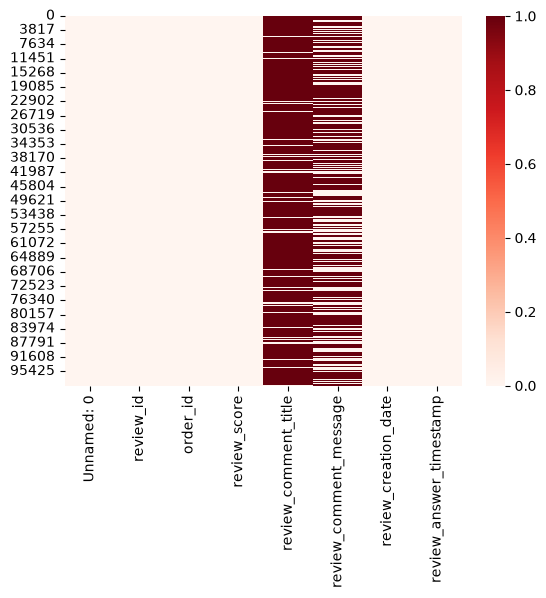

In [840]:
import seaborn as sns

sns.heatmap(silver_order_reviews.isna(), cmap="Reds")
plt.show()


In [838]:
silver_order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               99224 non-null  int64
 1   review_id                99224 non-null  str  
 2   order_id                 99224 non-null  str  
 3   review_score             99224 non-null  int64
 4   review_comment_title     11568 non-null  str  
 5   review_comment_message   40977 non-null  str  
 6   review_creation_date     99224 non-null  str  
 7   review_answer_timestamp  99224 non-null  str  
dtypes: int64(2), str(6)
memory usage: 18.6 MB


In [828]:
(silver_order_reviews['review_answer_timestamp'] < silver_order_reviews['review_creation_date']).sum()

np.int64(0)

In [ ]:
silver_order_reviews["review_score"].unique()  

array([4, 5, 1, 3, 2])

In [833]:
silver_order_reviews.duplicated().sum()

np.int64(0)

In [837]:
silver_order_reviews.loc[: , ['order_id' , 'review_id']].duplicated().sum()

np.int64(0)

In [841]:
date_cols = ["review_creation_date", "review_answer_timestamp"]
for var in date_cols:
    silver_order_reviews[var] = pd.to_datetime(silver_order_reviews[var], errors="coerce")


In [842]:
silver_order_reviews.to_parquet(r"..\data\silver\olist_order_reviews_dataset.parquet")

### Section 7 : Vérification de la qualité des données sur la table des vendeurs

In [850]:
silver_sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
seller_city_clean         2
dtype: int64

In [851]:
silver_sellers[silver_sellers["seller_city_clean"].isna() ]

,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean
517,ceb7b4fb9401cd378de7886317ad1b47,22790,04482255,RJ,NaN
2258,4b5f66b7adcf57f1ecc0d3c07dd6b177,87025,vendas@creditparts.com.br,PR,NaN


In [862]:
silver_sellers.loc[silver_sellers['seller_city'].str.contains(r'[0-9A-Z@$.]' , regex=True) , : ]

,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean
517,ceb7b4fb9401cd378de7886317ad1b47,22790,04482255,RJ,NaN
2258,4b5f66b7adcf57f1ecc0d3c07dd6b177,87025,vendas@creditparts.com.br,PR,NaN


In [867]:
silver_sellers.drop(columns = ["seller_city"] , axis = 0 , inplace= True )

In [868]:
silver_sellers.to_parquet(r"..\data\silver\olits_sellers.parquet")


## Conclusions Data Quality (Silver)

### Table des produits

- Aucun doublon n’a été détecté et chaque produit possède un identifiant unique.
- Les valeurs manquantes de `product_category_name` ont été remplacées par la catégorie `unknown` dans `silver_products`. Les autres valeurs manquantes ont été conservées afin d’éviter toute imputation arbitraire.
- Quatre produits présentaient un `product_weight_g` égal à `0`. Ces valeurs ont été considérées comme des mesures invalides et remplacées par `NaN`.
- La table `silver_products` a été construite à partir des données produits nettoyées et enrichies avec la traduction anglaise des catégories.
- Lorsqu’aucune traduction anglaise n’était disponible, le nom original en portugais a été conservé afin d’éviter toute perte d’information.

### Table des clients

- Aucun doublon n’a été détecté et chaque client possède un `customer_id` unique.
- Environ **24 % des codes postaux** avaient une longueur de 4 caractères. Cette situation est cohérente avec une perte du zéro initial due au stockage numérique de la variable.
- Les codes postaux ont donc été convertis en chaînes de caractères puis complétés à 5 caractères avec `zfill(5)`.

### Table des commandes

- Aucun doublon n’a été détecté et chaque commande possède un `order_id` unique.
- Les contrôles de cohérence temporelle ont été validés. Les dates suivent globalement l’ordre métier attendu : achat → approbation → remise au transporteur → livraison au client.
- Les anomalies connues sont identifiées par les indicateurs `dq_invalid_carrier_date` et `dq_invalid_delivery_sequence`.
- Ces anomalies sont conservées et pourront être exclues des analyses logistiques nécessitant une chronologie valide.

### Table des paiements

- Les paiements avec `payment_value = 0` ont été conservés. Pour les commandes vérifiables, les autres lignes de paiement couvrent déjà intégralement le montant des articles et des frais de livraison.
- Ces valeurs nulles ne correspondent donc pas nécessairement à des montants manquants. Un indicateur `dq_zero_payment` permet de les identifier.
- Un peu moins de **1 % des commandes présentes dans la table des paiements** ne possèdent pas de correspondance dans la table des avis et/ou dans la table des articles commandés. Ces cas sont conservés afin de ne pas supprimer arbitrairement des données.

### Table des articles commandés

- Aucun doublon n’a été détecté selon la clé définie pour les articles commandés.
- Aucune valeur manquante n’a été détectée.
- Aucun prix ou frais de livraison incohérent ou incompatible avec les règles de validation définies n’a été identifié.

### Table des avis clients

- Aucun doublon problématique n’a été détecté.
- Aucune incohérence temporelle n’a été identifiée.
- Les variables les plus touchées par les valeurs manquantes sont :
  - `review_comment_title` : **88,34 %**
  - `review_comment_message` : **58,70 %**
- Ces variables correspondent à des champs de texte libre. Les clients n’étant pas obligés de laisser un titre ou un commentaire, ces valeurs manquantes sont considérées comme naturelles et ne sont pas imputées.

### Table des vendeurs

- Aucun doublon n’a été détecté et chaque vendeur possède un `seller_id` unique.
- Les noms des villes ayant déjà été normalisés lors de l’étape précédente de Data Quality, la colonne originale a été supprimée et seule la version normalisée a été conservée.

### Conclusion générale

À l’issue des contrôles de qualité, les données ont été nettoyées, standardisées et validées tout en conservant les anomalies métier pertinentes sous forme d’indicateurs de qualité. Les transformations ont volontairement limité les imputations afin d’éviter l’introduction de valeurs artificielles. Les tables Silver sont désormais suffisamment structurées et cohérentes pour servir de base à la construction de la couche **Gold**, aux KPI et aux analyses du projet Customer 360.